In [3]:
from __future__ import print_function
from matplotlib import pyplot as plt
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
import coremltools
from scipy import stats
from IPython.display import display, HTML

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Reshape
from keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.utils import to_categorical

scikit-learn version 1.7.0 is not supported. Minimum required version: 0.17. Maximum required version: 1.5.1. Disabling scikit-learn conversion API.
TensorFlow version 2.21.0 has not been tested with coremltools. You may run into unexpected errors. TensorFlow 2.12.0 is the most recent version that has been tested.
Torch version 2.10.0+cu128 has not been tested with coremltools. You may run into unexpected errors. Torch 2.7.0 is the most recent version that has been tested.
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLCPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLGPUComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLNeuralEngineComputeDeviceProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLModelProxy: No module named 'coremltools.libcoremlpython'
Failed to load _MLComputePlanProxy: No module named 'coremltools.libcoremlpython'
Failed to load _ML

In [4]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

W0000 00:00:1777911871.795061   37287 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777911871.875788   37287 gpu_device.cc:2043] Created device /device:GPU:0 with 12936 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 3589711025949572071
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 13565165568
locality {
  bus_id: 1
  links {
  }
}
incarnation: 18278054566820126604
physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a"
xla_global_id: 416903419
]


In [5]:
  import os
  os.chdir('/home/g00n3r/projects/esp32_cl_har')

  column_names = ['user-id', 'activity', 'timestamp', 'x-axis', 'y-axis', 'z-axis']
  df = pd.read_csv("data/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt",
                   header=None,
                   names=column_names,
                   on_bad_lines='skip')
  df['z-axis'] = df['z-axis'].replace(regex=True, to_replace=r';', value=r'')
  df['z-axis'] = df['z-axis'].apply(lambda x: float(str(x).replace(',', '.')))
  df.dropna(axis=0, how='any', inplace=True)
  df.head(20)

,user-id,activity,timestamp,x-axis,y-axis,z-axis
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164
5,33,Jogging,49106442306000,1.375655,-2.492524,-6.510526
6,33,Jogging,49106542312000,-0.612916,10.569390,5.706926
7,33,Jogging,49106652389000,-0.503953,13.947236,7.055340
8,33,Jogging,49106762313000,-8.430995,11.413852,5.134871
9,33,Jogging,49106872299000,0.953424,1.375655,1.648062


In [6]:
print('Number of columns in the dataframe: %i' % (df.shape[1]))
print('Number of rows in the dataframe: %i\n' % (df.shape[0]))

Number of columns in the dataframe: 6
Number of rows in the dataframe: 1086465



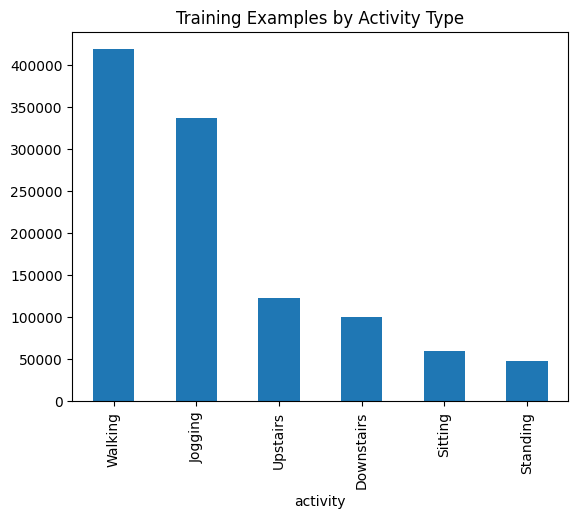

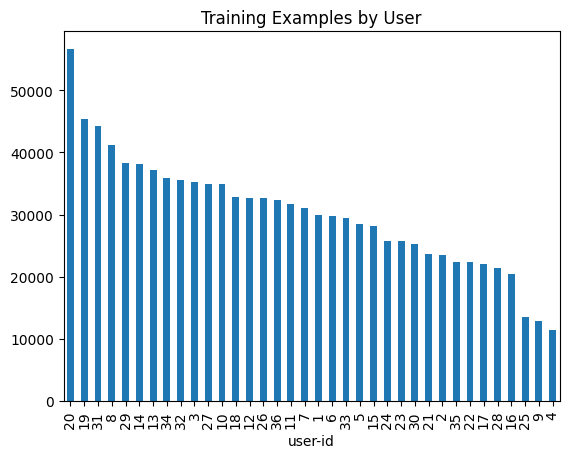

In [7]:
# Show how many training examples exist for each of the six activities
df['activity'].value_counts().plot(kind='bar',
                                   title='Training Examples by Activity Type')
plt.show()
# Better understand how the recordings are spread across the different
# users who participated in the study
df['user-id'].value_counts().plot(kind='bar',
                                  title='Training Examples by User')
plt.show()

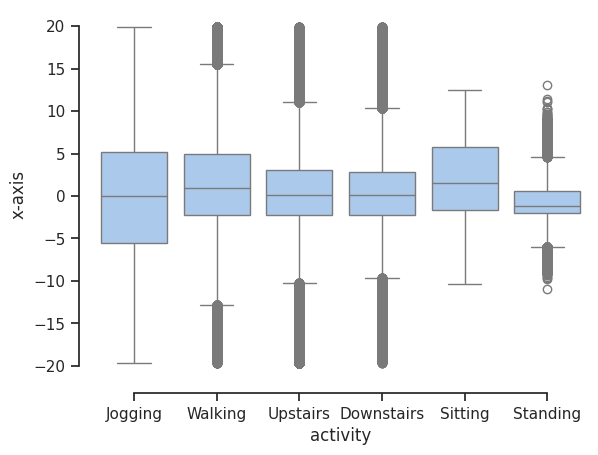

In [8]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

# Draw a nested boxplot to show bills by day and time
sns.boxplot(data=df, x="activity", y="x-axis")
sns.despine(offset=10, trim=True)

## Розподіл прискорення по осі X для кожного типу активності

Boxplot відображає розподіл значень акселерометра (вісь X) по 6 класах активності з датасету WISDM.

- **Медіана** — горизонтальна лінія всередині box
- **IQR (25–75%)** — висота box
- **Вуса** — розкид без викидів

> Jogging і Upstairs мають найбільший розкид — характерно для динамічних рухів. Walking, Downstairs, Standing, Sitting — більш стабільні.


In [9]:
standing = df[df['activity'] == 'Standing']

Q1 = standing['x-axis'].quantile(0.25)
Q3 = standing['x-axis'].quantile(0.75)
IQR = Q3 - Q1

outliers = standing[
  (standing['x-axis'] < Q1 - 1.5 * IQR) |
  (standing['x-axis'] > Q3 + 1.5 * IQR)
]

print(f"Кількість викидів: {len(outliers)}")
print(outliers[['user-id', 'activity', 'x-axis']].describe())
outliers

Кількість викидів: 6095
           user-id       x-axis
count  6095.000000  6095.000000
mean     13.880886    -3.677358
std      10.377211     6.429887
min       5.000000   -10.990000
25%       7.000000    -7.930000
50%       8.000000    -7.350000
75%      31.000000     5.600000
max      31.000000    13.100000


,user-id,activity,timestamp,x-axis,y-axis,z-axis
223560,27,Standing,12542372296000,5.52,10.65,-2.451662
223561,27,Standing,12542422315000,-6.51,10.12,0.231546
400183,5,Standing,3210412273000,-6.66,6.32,-1.225831
542602,13,Standing,858492259000,-6.13,7.97,0.610000
542611,13,Standing,858942363000,-6.66,8.39,0.190000
...,...,...,...,...,...,...
1083695,19,Standing,131466241640000,-6.02,7.82,-0.500000
1083696,19,Standing,131466281496000,-6.09,7.78,-0.530000
1083724,19,Standing,131467691438000,-6.21,7.63,-0.530000
1083757,19,Standing,131469332857000,-6.09,8.47,0.080000


In [10]:
ACTIVITY_ORDER = ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']
FEATURE_COLUMNS = ['x', 'y', 'z']

df_model = df.copy().rename(
    columns={
        'user-id': 'user_id',
        'x-axis': 'x',
        'y-axis': 'y',
        'z-axis': 'z',
    }
)

df_model = df_model[df_model['activity'].isin(ACTIVITY_ORDER)].copy()

df_model['user_id'] = pd.to_numeric(df_model['user_id'], errors='coerce')
df_model['timestamp'] = pd.to_numeric(df_model['timestamp'], errors='coerce')
df_model[FEATURE_COLUMNS] = df_model[FEATURE_COLUMNS].apply(pd.to_numeric,
errors='coerce')

df_model = df_model.dropna(subset=['user_id', 'timestamp', *FEATURE_COLUMNS]).copy()
df_model['user_id'] = df_model['user_id'].astype(np.int32)
df_model['timestamp'] = df_model['timestamp'].astype(np.int64)

df_model = df_model.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

activity_to_label = {activity: idx for idx, activity in enumerate(ACTIVITY_ORDER)}
label_to_activity = {idx: activity for activity, idx in activity_to_label.items()}
df_model['label'] = df_model['activity'].map(activity_to_label).astype(np.int32)

print(f"Rows after cleanup: {len(df_model):,}")
print(f"Subjects: {df_model['user_id'].nunique()}")
print(f"Activities: {sorted(df_model['activity'].unique().tolist())}")

display(df_model.groupby('activity').size().rename('rows').to_frame())
display(df_model.groupby('user_id')['activity'].nunique().describe().to_frame().T)

df_model.head()

Rows after cleanup: 1,086,465
Subjects: 36
Activities: ['Downstairs', 'Jogging', 'Sitting', 'Standing', 'Upstairs', 'Walking']


,rows
activity,
Downstairs,100425
Jogging,336445
Sitting,59939
Standing,48394
Upstairs,122869
Walking,418393


,count,mean,std,min,25%,50%,75%,max
activity,36.0,4.972222,1.341345,1.0,4.0,6.0,6.0,6.0


,user_id,activity,timestamp,x,y,z,label
0,1,Walking,4991922345000,0.69,10.80,-2.03,0
1,1,Walking,4991972333000,6.85,7.44,-0.50,0
2,1,Walking,4992022351000,0.93,5.63,-0.50,0
3,1,Walking,4992072339000,-2.11,5.01,-0.69,0
4,1,Walking,4992122358000,-4.59,4.29,-1.95,0


In [11]:
feature_means = df_model[FEATURE_COLUMNS].mean()
feature_stds = df_model[FEATURE_COLUMNS].std()

df_model_z = df_model.copy()
df_model_z[FEATURE_COLUMNS] = (
    df_model_z[FEATURE_COLUMNS] - feature_means
) / feature_stds

print("Feature means before z-score:")
display(feature_means.to_frame(name='mean').T)

print("Feature stds before z-score:")
display(feature_stds.to_frame(name='std').T)

print("Feature means after z-score:")
display(df_model_z[FEATURE_COLUMNS].mean().to_frame(name='mean').T)

print("Feature stds after z-score:")
display(df_model_z[FEATURE_COLUMNS].std().to_frame(name='std').T)

df_model_z.head()

Feature means before z-score:


,x,y,z
mean,0.664113,7.246045,0.397697


Feature stds before z-score:


,x,y,z
std,6.876277,6.739789,4.761111


Feature means after z-score:


,x,y,z
mean,-6.864332e-17,-3.637259e-16,7.785157e-17


Feature stds after z-score:


,x,y,z
std,1.0,1.0,1.0


,user_id,activity,timestamp,x,y,z,label
0,1,Walking,4991922345000,0.003765,0.527310,-0.509901,0
1,1,Walking,4991972333000,0.899598,0.028778,-0.188548,0
2,1,Walking,4992022351000,0.038667,-0.239777,-0.188548,0
3,1,Walking,4992072339000,-0.403432,-0.331768,-0.228455,0
4,1,Walking,4992122358000,-0.764093,-0.438596,-0.493099,0


In [12]:
WINDOW_SIZE = 80
STEP_SIZE = 40  # 50% overlap

def create_windows(dataframe, feature_columns, window_size=80, step_size=40):
    windows = []
    labels = []
    subject_ids = []

    grouped = dataframe.groupby(['user_id', 'activity'], sort=False)

    for (user_id, activity), group in grouped:
        values = group[feature_columns].to_numpy(dtype=np.float32)
        label = int(group['label'].iloc[0])

        if len(values) < window_size:
            continue

        for start in range(0, len(values) - window_size + 1, step_size):
            end = start + window_size
            window = values[start:end]

            windows.append(window)
            labels.append(label)
            subject_ids.append(user_id)

    X = np.stack(windows).astype(np.float32)
    y = np.asarray(labels, dtype=np.int32)
    subjects = np.asarray(subject_ids, dtype=np.int32)

    return X, y, subjects

X, y, subjects = create_windows(
    df_model_z,
    FEATURE_COLUMNS,
    window_size=WINDOW_SIZE,
    step_size=STEP_SIZE,
)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"subjects shape: {subjects.shape}")
print(f"Window dtype: {X.dtype}")

print("Class distribution in windows:")
display(pd.Series(y).map(label_to_activity).value_counts().rename_axis('activity').to_frame('windows'))

print("Unique subjects in windows:", len(np.unique(subjects)))
print("First window shape:", X[0].shape)
print("First window label:", y[0], label_to_activity[y[0]])

X shape: (26893, 80, 3)
y shape: (26893,)
subjects shape: (26893,)
Window dtype: float32
Class distribution in windows:


,windows
activity,
Walking,10406
Jogging,8362
Upstairs,3025
Downstairs,2463
Sitting,1464
Standing,1173


Unique subjects in windows: 36
First window shape: (80, 3)
First window label: 0 Walking


In [13]:
print("NaN in X:", np.isnan(X).sum())
print("Inf in X:", np.isinf(X).sum())
print("NaN in y:", np.isnan(y).sum())

subject_window_counts = pd.Series(subjects).value_counts().sort_index()
print("Windows per subject:")
display(subject_window_counts.to_frame(name='n_windows'))

y_onehot = to_categorical(y, num_classes=len(ACTIVITY_ORDER))

print("y_onehot shape:", y_onehot.shape)
print("Classes:", ACTIVITY_ORDER)
print("Min windows per subject:", subject_window_counts.min())
print("Max windows per subject:", subject_window_counts.max())

NaN in X: 0
Inf in X: 0
NaN in y: 0
Windows per subject:


,n_windows
1,744
2,585
3,871
4,277
5,704
6,732
7,766
8,1020
9,322
10,865


y_onehot shape: (26893, 6)
Classes: ['Walking', 'Jogging', 'Upstairs', 'Downstairs', 'Sitting', 'Standing']
Min windows per subject: 277
Max windows per subject: 1407


In [14]:
from tensorflow import keras
from tensorflow.keras import layers

NUM_CLASSES = len(ACTIVITY_ORDER)
INPUT_SHAPE = (WINDOW_SIZE, len(FEATURE_COLUMNS))

def build_baseline_model(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', padding='same'),
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(num_classes, activation='softmax'),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

W0000 00:00:1777911874.790547   37287 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1777911874.793174   37287 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1777911874.794851   37287 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12936 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Ti, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 80, 32)         │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 80, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,110 (27.77 KB)

 Trainable params: 7,110 (27.77 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
TEST_SUBJECT_ID = 1
BATCH_SIZE = 64
EPOCHS = 10

train_mask = subjects != TEST_SUBJECT_ID
test_mask = subjects == TEST_SUBJECT_ID

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y_onehot[train_mask], y_onehot[test_mask]

print(f"Train windows: {X_train.shape[0]}")
print(f"Test windows: {X_test.shape[0]}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

model = build_baseline_model()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Train windows: 26149
Test windows: 744
Train shape: (26149, 80, 3)
Test shape: (744, 80, 3)
Epoch 1/10


I0000 00:00:1777911960.857756  159623 service.cc:153] XLA service 0x7ef6d40432e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777911960.857774  159623 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Ti, Compute Capability 12.0a (Driver: 12.9.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1777911960.893098  159623 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777911960.989599  159623 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1777911960.995530  159623 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1533__.18
I0000 00:00:1777911961.725168  160510 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads



112/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5311 - loss: 1.4018

I0000 00:00:1777911963.015451  159623 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


390/409 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6318 - loss: 1.1030

I0000 00:00:1777911963.713902  159623 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1533__.18
I0000 00:00:1777911963.818181  160666 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 4 bytes spill stores, 4 bytes spill loads



409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6359 - loss: 1.0901

I0000 00:00:1777911965.862567  160883 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_2', 4 bytes spill stores, 4 bytes spill loads



409/409 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7204 - loss: 0.8191 - val_accuracy: 0.8024 - val_loss: 0.5544
Epoch 2/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.8436 - loss: 0.4366 - val_accuracy: 0.8172 - val_loss: 0.6308
Epoch 3/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8754 - loss: 0.3516 - val_accuracy: 0.8185 - val_loss: 0.6515
Epoch 4/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8969 - loss: 0.2989 - val_accuracy: 0.8185 - val_loss: 0.6224
Epoch 5/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9128 - loss: 0.2591 - val_accuracy: 0.8387 - val_loss: 0.6109
Epoch 6/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9226 - loss: 0.2340 - val_accuracy: 0.8629 - val_loss: 0.5175
Epoch 7/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 0s 880us/step - accuracy: 0.9320 - loss: 0.2124 - val_accuracy: 0.8253 - val_loss: 0.5136
Epoch 8/10
409/409 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9357 - loss: 0.1973 - val_accuracy: 0.8656 - 